# NLP Project 1 – Hate Speech Classification Pipeline

**Dataset:** [Jigsaw Toxic Comment Classification](https://www.kaggle.com/c/jigsaw-toxic-comment-classification-challenge/data)  
**Goal:** Systematically compare preprocessing, feature extraction, and models.  
**Principle:** Change one variable at a time, keep the others fixed at baseline.

| ID | What changes | Fixed |
|---|---|---|
| E1 | – (Baseline) | TF-IDF 1000 + SVM |
| E2 | No preprocessing | TF-IDF 1000 + SVM |
| E3 | No stemming | TF-IDF 1000 + SVM |
| E4 | No stopword removal | TF-IDF 1000 + SVM |
| E5 | Bag of Words instead of TF-IDF | Baseline prep + SVM |
| E6 | TF-IDF with 5000 features | Baseline prep + SVM |
| E7 | Logistic Regression | Baseline prep + TF-IDF 1000 |
| E8 | Naive Bayes | Baseline prep + TF-IDF 1000 |
| E9 | SVM C=0.1 / C=1.0 / C=10 | Baseline prep + TF-IDF 1000 |

## 0. Setup

In [1]:
import nltk
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\sarru\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\sarru\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
from matplotlib.patches import Patch
matplotlib.rcParams['figure.dpi'] = 120

from pipeline_functions import load_and_preprocess, preprocess, get_vectorizer, get_model, run_experiment

# Dictionary to collect all results
results = {}

# define data path
train_file = 'data/train.csv'
print('Setup complete.')

Setup complete.


## 1. Dataset Overview

In [3]:
df_train = pd.read_csv(train_file, encoding='utf-8')
print('Shape:', df_train.shape)
print('\nColumns:', df_train.columns.tolist())
display(df_train.head())

print("\n--- Checking for Missing Values ---")
print(df_train.isnull().sum())


Shape: (159571, 8)

Columns: ['id', 'comment_text', 'toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate']


,id,comment_text,toxic,severe_toxic,obscene,threat,insult,identity_hate
0,0000997932d777bf,Explanation\nWhy the edits made under my usern...,0,0,0,0,0,0
1,000103f0d9cfb60f,D'aww! He matches this background colour I'm s...,0,0,0,0,0,0
2,000113f07ec002fd,"Hey man, I'm really not trying to edit war. It...",0,0,0,0,0,0
3,0001b41b1c6bb37e,"""\nMore\nI can't make any real suggestions on ...",0,0,0,0,0,0
4,0001d958c54c6e35,"You, sir, are my hero. Any chance you remember...",0,0,0,0,0,0



--- Checking for Missing Values ---
id               0
comment_text     0
toxic            0
severe_toxic     0
obscene          0
threat           0
insult           0
identity_hate    0
dtype: int64


#### Label Distribution

Not Hate Speech: 143346 (89.8%)
Hate Speech:     16225 (10.2%)


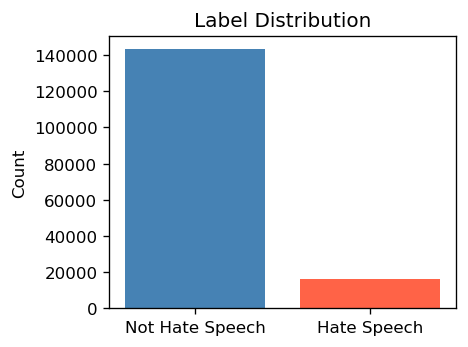

In [4]:
# Label distribution (binary: Hate Speech if any of the 6 labels is 1)
df_train['binary_label'] = df_train[['toxic','severe_toxic','obscene','threat','insult','identity_hate']].max(axis=1)
counts = df_train['binary_label'].value_counts()
print('Not Hate Speech:', counts[0], f'({100*counts[0]/len(df_train):.1f}%)')
print('Hate Speech:    ', counts[1], f'({100*counts[1]/len(df_train):.1f}%)')

fig, ax = plt.subplots(figsize=(4, 3))
ax.bar(['Not Hate Speech', 'Hate Speech'], [counts[0], counts[1]], color=['steelblue', 'tomato'])
ax.set_title('Label Distribution')
ax.set_ylabel('Count')
plt.tight_layout()
plt.savefig('figures/fig_label_distribution.png', bbox_inches='tight')
plt.show()

#### Text Length Distribution (Words)

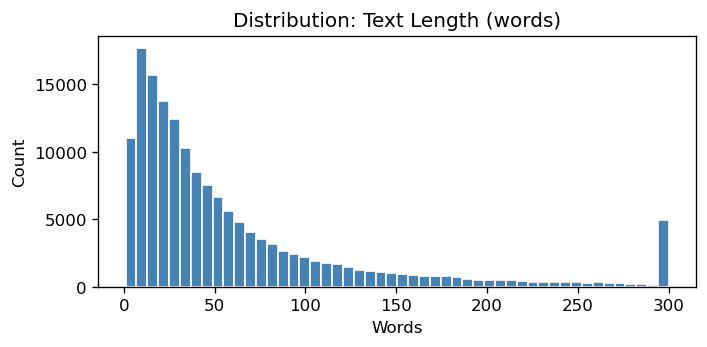

count    159571.0
mean         67.3
std          99.2
min           1.0
25%          17.0
50%          36.0
75%          75.0
max        1411.0
Name: text_len, dtype: float64


In [5]:
# Text length distribution
df_train['text_len'] = df_train['comment_text'].str.split().str.len()

fig, ax = plt.subplots(figsize=(6, 3))
ax.hist(df_train['text_len'].clip(upper=300), bins=50, color='steelblue', edgecolor='white')
ax.set_title('Distribution: Text Length (words)')
ax.set_xlabel('Words')
ax.set_ylabel('Count')
plt.tight_layout()
plt.savefig('figures/fig_text_length.png', bbox_inches='tight')
plt.show()

print(df_train['text_len'].describe().round(1))

#### Outlier Detection

=== Outliers (IQR-Methode) ===
Untere Grenze: -70 Wörter
Obere Grenze:  162 Wörter
Anzahl Outliers: 14402 (9.0%)
Davon Hate Speech: 912


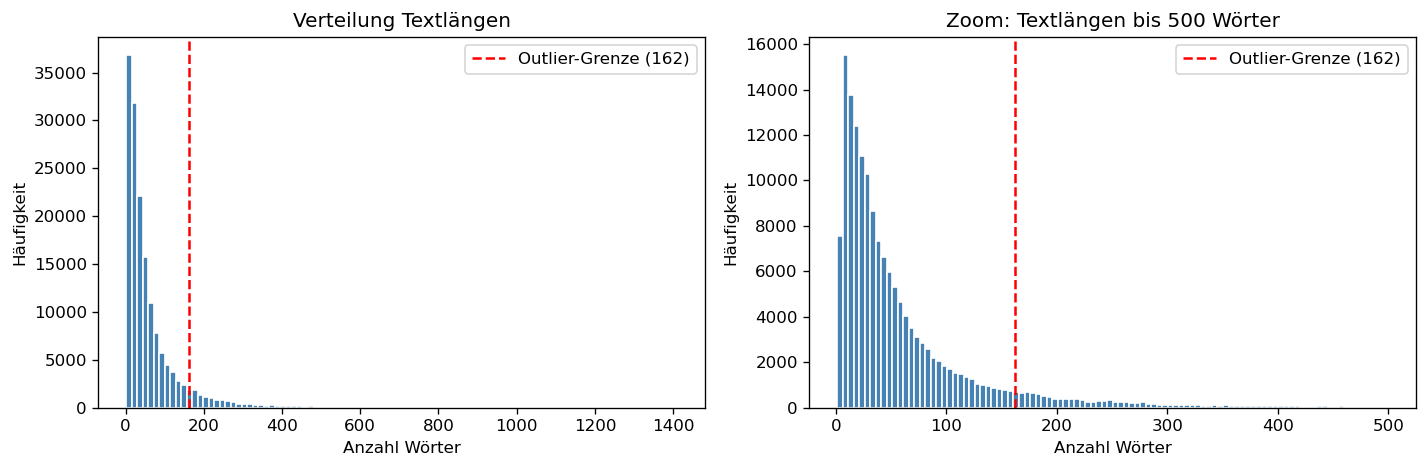

Figure gespeichert als fig_outlier_detection.png


In [6]:
# Outlier Detection
Q1 = df_train['text_len'].quantile(0.25)
Q3 = df_train['text_len'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df_train[(df_train['text_len'] < lower) | (df_train['text_len'] > upper)]
print(f"=== Outliers (IQR-Methode) ===")
print(f"Untere Grenze: {lower:.0f} Wörter")
print(f"Obere Grenze:  {upper:.0f} Wörter")
print(f"Anzahl Outliers: {len(outliers)} ({100*len(outliers)/len(df_train):.1f}%)")
hate_cols = ['toxic','severe_toxic','obscene','threat','insult','identity_hate']
print(f"Davon Hate Speech: {outliers[outliers[hate_cols].max(axis=1)==1].shape[0]}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(df_train['text_len'], bins=100, color='steelblue', edgecolor='white')
axes[0].axvline(upper, color='red', linestyle='--', label=f'Outlier-Grenze ({upper:.0f})')
axes[0].set_title('Verteilung Textlängen')
axes[0].set_xlabel('Anzahl Wörter')
axes[0].set_ylabel('Häufigkeit')
axes[0].legend()

axes[1].hist(df_train[df_train['text_len'] <= 500]['text_len'], bins=100, color='steelblue', edgecolor='white')
axes[1].axvline(upper, color='red', linestyle='--', label=f'Outlier-Grenze ({upper:.0f})')
axes[1].set_title('Zoom: Textlängen bis 500 Wörter')
axes[1].set_xlabel('Anzahl Wörter')
axes[1].set_ylabel('Häufigkeit')
axes[1].legend()

plt.tight_layout()
plt.savefig('figures/fig_outlier_detection.png', bbox_inches='tight')
plt.show()
print("Figure gespeichert als fig_outlier_detection.png")

---
## 2. Experiments

⚠️ **First run:** Cache files (`cache_*_X.pkl`) will be created automatically – this takes a few minutes per new preprocessing config.  
⏱️ **Runtime:** ~1-3 min per experiment with `downsample=True`.  
💡 **Tip:** Each experiment is independent – if one fails, just re-run that cell.

### E1 – Baseline
**Preprocessing:** Tokenize + Stopword removal + Stemming + Remove numbers  
**Features:** TF-IDF (1000)  
**Model:** SVM

In [7]:
X_e1, Y_e1 = load_and_preprocess(
    train_file,
    preprocess_fn=lambda t: preprocess(t, remove_stopwords=True, remove_numbers=True, do_stem=True),
    cache_path='cache_stem+stop'
)

vectorizer_e1 = get_vectorizer('tfidf', max_features=1000)
model_e1      = get_model('svm')

results['E1'] = run_experiment(X_e1, Y_e1, vectorizer_e1, model_e1, downsample=False, verbose=True)
print(f"\nE1 → F1 Macro: {results['E1']['f1_macro']} | F1 Hate Speech: {results['E1']['f1_hate_speech']}")

Processing row 159570


Saved to cache: cache_stem+stop
Duplicates removed: 1927 | Remaining: 157644 | Distribution: Counter({0: 141635, 1: 16009})
                 precision    recall  f1-score   support

not Hate Speech       0.97      0.95      0.96     28327
    Hate Speech       0.64      0.74      0.69      3202

       accuracy                           0.93     31529
      macro avg       0.81      0.85      0.82     31529
   weighted avg       0.94      0.93      0.93     31529


E1 → F1 Macro: 0.8235 | F1 Hate Speech: 0.6855


### E2 – No Preprocessing
**Research question:** Does preprocessing actually help?  
**Preprocessing:** Only tokenize – no stopword removal, no stemming  
**Features:** TF-IDF (1000)
**Model:** SVM

In [8]:
X_e2, Y_e2 = load_and_preprocess(
    train_file,
    preprocess_fn=lambda t: preprocess(t, remove_stopwords=False, remove_numbers=False, do_stem=False),
    cache_path='cache_none'
)

vectorizer_e2 = get_vectorizer('tfidf', max_features=1000)
model_e2      = get_model('svm')

results['E2'] = run_experiment(X_e2, Y_e2, vectorizer_e2, model_e2, downsample=False, verbose=True)
print(f"\nE2 → F1 Macro: {results['E2']['f1_macro']} | F1 Hate Speech: {results['E2']['f1_hate_speech']}")

Processing row 2

Processing row 159570


Saved to cache: cache_none
Duplicates removed: 801 | Remaining: 158770 | Distribution: Counter({0: 142653, 1: 16117})
                 precision    recall  f1-score   support

not Hate Speech       0.97      0.96      0.97     28531
    Hate Speech       0.68      0.75      0.71      3223

       accuracy                           0.94     31754
      macro avg       0.83      0.85      0.84     31754
   weighted avg       0.94      0.94      0.94     31754


E2 → F1 Macro: 0.8385 | F1 Hate Speech: 0.7114


### E3 – Stopwords only (no Stemming)
**Research question:** Does stemming help? Word forms like 'killed' vs 'kill' might be relevant for hate speech.  
**Preprocessing:** Tokenize + Stopword removal (no stemming)  
**Features:** TF-IDF (1000)  
**Model:** SVM

In [9]:
X_e3, Y_e3 = load_and_preprocess(
    train_file,
    preprocess_fn=lambda t: preprocess(t, remove_stopwords=True, remove_numbers=True, do_stem=False),
    cache_path='cache_stop'
)

vectorizer_e3 = get_vectorizer('tfidf', max_features=1000)
model_e3      = get_model('svm')

results['E3'] = run_experiment(X_e3, Y_e3, vectorizer_e3, model_e3, downsample=False, verbose=True)
print(f"\nE3 → F1 Macro: {results['E3']['f1_macro']} | F1 Hate Speech: {results['E3']['f1_hate_speech']}")

Processing row 12

Processing row 159570


Saved to cache: cache_stop
Duplicates removed: 1774 | Remaining: 157797 | Distribution: Counter({0: 141768, 1: 16029})
                 precision    recall  f1-score   support

not Hate Speech       0.97      0.95      0.96     28354
    Hate Speech       0.63      0.71      0.67      3206

       accuracy                           0.93     31560
      macro avg       0.80      0.83      0.81     31560
   weighted avg       0.93      0.93      0.93     31560


E3 → F1 Macro: 0.8129 | F1 Hate Speech: 0.6665


### E4 – Stemming only (no Stopwords)
**Research question:** Do stopwords help? Words like 'you' or 'I' might actually signal aggression.  
**Preprocessing:** Tokenize + Stemming (no stopword removal)  
**Features:** TF-IDF (1000) ← fixed  
**Model:** SVM ← fixed

In [10]:
X_e4, Y_e4 = load_and_preprocess(
    train_file,
    preprocess_fn=lambda t: preprocess(t, remove_stopwords=False, remove_numbers=True, do_stem=True),
    cache_path='cache_stem'
)

vectorizer_e4 = get_vectorizer('tfidf', max_features=1000)
model_e4      = get_model('svm')

results['E4'] = run_experiment(X_e4, Y_e4, vectorizer_e4, model_e4, downsample=False, verbose=True)
print(f"\nE4 → F1 Macro: {results['E4']['f1_macro']} | F1 Hate Speech: {results['E4']['f1_hate_speech']}")

Processing row 159570


Saved to cache: cache_stem
Duplicates removed: 1312 | Remaining: 158259 | Distribution: Counter({0: 142172, 1: 16087})
                 precision    recall  f1-score   support

not Hate Speech       0.97      0.97      0.97     28435
    Hate Speech       0.71      0.76      0.74      3217

       accuracy                           0.94     31652
      macro avg       0.84      0.86      0.85     31652
   weighted avg       0.95      0.94      0.95     31652


E4 → F1 Macro: 0.8523 | F1 Hate Speech: 0.7355


### E5 – Bag of Words
**Research question:** Does TF-IDF weighting help compared to raw word counts?  
**Preprocessing:** Stem + Stopwords  
**Features:** Bag of Words (1000)  
**Model:** SVM  

In [11]:
# Reuses cached baseline preprocessing
X_e5, Y_e5 = load_and_preprocess(
    train_file,
    preprocess_fn=lambda t: preprocess(t, remove_stopwords=True, remove_numbers=True, do_stem=True),
    cache_path='cache_stem+stop'
)

vectorizer_e5 = get_vectorizer('bow', max_features=1000)
model_e5      = get_model('svm')

results['E5'] = run_experiment(X_e5, Y_e5, vectorizer_e5, model_e5, downsample=False, verbose=True)
print(f"\nE5 → F1 Macro: {results['E5']['f1_macro']} | F1 Hate Speech: {results['E5']['f1_hate_speech']}")

Loaded from cache: cache_stem+stop
                 precision    recall  f1-score   support

not Hate Speech       0.97      0.93      0.95     28327
    Hate Speech       0.56      0.76      0.65      3202

       accuracy                           0.92     31529
      macro avg       0.77      0.85      0.80     31529
   weighted avg       0.93      0.92      0.92     31529


E5 → F1 Macro: 0.7994 | F1 Hate Speech: 0.6468


### E6 – TF-IDF with 5000 features
**Research question:** Does a larger vocabulary improve classification?  
**Preprocessing:** Stem + Stopwords ← fixed (Baseline)  
**Features:** TF-IDF (5000)  
**Model:** SVM ← fixed

In [12]:
# Reuses cached baseline preprocessing
X_e6, Y_e6 = load_and_preprocess(
    train_file,
    preprocess_fn=lambda t: preprocess(t, remove_stopwords=True, remove_numbers=True, do_stem=True),
    cache_path='cache_stem+stop'
)

vectorizer_e6 = get_vectorizer('tfidf', max_features=5000)
model_e6      = get_model('svm')

results['E6'] = run_experiment(X_e6, Y_e6, vectorizer_e6, model_e6, downsample=False, verbose=True)
print(f"\nE6 → F1 Macro: {results['E6']['f1_macro']} | F1 Hate Speech: {results['E6']['f1_hate_speech']}")

Loaded from cache: cache_stem+stop
                 precision    recall  f1-score   support

not Hate Speech       0.97      0.98      0.98     28327
    Hate Speech       0.79      0.77      0.78      3202

       accuracy                           0.96     31529
      macro avg       0.88      0.87      0.88     31529
   weighted avg       0.95      0.96      0.96     31529


E6 → F1 Macro: 0.8766 | F1 Hate Speech: 0.7779


### E7 – Logistic Regression
**Research question:** Is a simpler, faster model competitive with SVM?  
**Preprocessing:** Stem + Stopwords ← fixed (Baseline)  
**Features:** TF-IDF (1000) ← fixed  
**Model:** Logistic Regression  
ℹ️ Fast enough to run on full dataset (`downsample=False`)

In [13]:
# Reuses cached baseline preprocessing
X_e7, Y_e7 = load_and_preprocess(
    train_file,
    preprocess_fn=lambda t: preprocess(t, remove_stopwords=True, remove_numbers=True, do_stem=True),
    cache_path='cache_stem+stop'
)

vectorizer_e7 = get_vectorizer('tfidf', max_features=1000)
model_e7      = get_model('logreg')

results['E7'] = run_experiment(X_e7, Y_e7, vectorizer_e7, model_e7, downsample=False, verbose=True)
print(f"\nE7 → F1 Macro: {results['E7']['f1_macro']} | F1 Hate Speech: {results['E7']['f1_hate_speech']}")

Loaded from cache: cache_stem+stop
                 precision    recall  f1-score   support

not Hate Speech       0.98      0.90      0.94     28327
    Hate Speech       0.48      0.82      0.61      3202

       accuracy                           0.89     31529
      macro avg       0.73      0.86      0.77     31529
   weighted avg       0.93      0.89      0.90     31529


E7 → F1 Macro: 0.7725 | F1 Hate Speech: 0.6071


### E8 – Naive Bayes
**Research question:** How does the classic text classifier compare to SVM?  
**Preprocessing:** Stem + Stopwords ← fixed (Baseline)  
**Features:** TF-IDF (1000) ← fixed  
**Model:** Multinomial Naive Bayes  
ℹ️ Fast enough to run on full dataset (`downsample=False`)

In [14]:
# Reuses cached baseline preprocessing
X_e8, Y_e8 = load_and_preprocess(
    train_file,
    preprocess_fn=lambda t: preprocess(t, remove_stopwords=True, remove_numbers=True, do_stem=True),
    cache_path='cache_stem+stop'
)

vectorizer_e8 = get_vectorizer('tfidf', max_features=1000)
model_e8      = get_model('naivebayes')

results['E8'] = run_experiment(X_e8, Y_e8, vectorizer_e8, model_e8, downsample=False, verbose=True)
print(f"\nE8 → F1 Macro: {results['E8']['f1_macro']} | F1 Hate Speech: {results['E8']['f1_hate_speech']}")

Loaded from cache: cache_stem+stop
                 precision    recall  f1-score   support

not Hate Speech       0.94      1.00      0.97     28327
    Hate Speech       0.97      0.45      0.61      3202

       accuracy                           0.94     31529
      macro avg       0.96      0.72      0.79     31529
   weighted avg       0.94      0.94      0.93     31529


E8 → F1 Macro: 0.7907 | F1 Hate Speech: 0.6126


### E9 – SVM Hyperparameter Tuning (C-value)
**Research question:** How does the SVM regularization parameter C affect performance?  
**Preprocessing:** Stem + Stopwords ← fixed (Baseline)  
**Features:** TF-IDF (1000) ← fixed  
**Model:** SVM with C ∈ {0.1, 1, 10}  
ℹ️C controls the trade-off between margin maximization and misclassification penalty

In [15]:
# Reuses cached baseline preprocessing
X_e9, Y_e9 = load_and_preprocess(
    train_file,
    preprocess_fn=lambda t: preprocess(t, remove_stopwords=True, remove_numbers=True, do_stem=True),
    cache_path='cache_stem+stop'
)

C_values = [0.1, 1, 10]
for C in C_values:
    exp_id = f'E9_C{C}'
    print(f'\n── SVM C={C} ──')
    vectorizer = get_vectorizer('tfidf', max_features=1000)
    model = get_model('svm', C=C)
    results[exp_id] = run_experiment(X_e9, Y_e9, vectorizer, model, downsample=False, verbose=True)
    print(f'{exp_id} → F1 Macro: {results[exp_id]["f1_macro"]} | F1 Hate Speech: {results[exp_id]["f1_hate_speech"]}')


Loaded from cache: cache_stem+stop

── SVM C=0.1 ──
                 precision    recall  f1-score   support

not Hate Speech       0.98      0.92      0.95     28327
    Hate Speech       0.54      0.80      0.64      3202

       accuracy                           0.91     31529
      macro avg       0.76      0.86      0.80     31529
   weighted avg       0.93      0.91      0.92     31529

E9_C0.1 → F1 Macro: 0.7951 | F1 Hate Speech: 0.6417

── SVM C=1 ──
                 precision    recall  f1-score   support

not Hate Speech       0.97      0.95      0.96     28327
    Hate Speech       0.64      0.74      0.69      3202

       accuracy                           0.93     31529
      macro avg       0.81      0.85      0.82     31529
   weighted avg       0.94      0.93      0.93     31529

E9_C1 → F1 Macro: 0.8235 | F1 Hate Speech: 0.6855

── SVM C=10 ──
                 precision    recall  f1-score   support

not Hate Speech       0.96      0.97      0.96     28327
    Hate S

---
## 3. Results

In [16]:
experiment_meta = {
    'E1': ('Baseline',             'Stem + Stopwords', 'TF-IDF (1000)',  'SVM'),
    'E2': ('No Preprocessing',     'None',             'TF-IDF (1000)',  'SVM'),
    'E3': ('Stopwords only',       'Stopwords',        'TF-IDF (1000)',  'SVM'),
    'E4': ('Stemming only',        'Stemming',         'TF-IDF (1000)',  'SVM'),
    'E5': ('Bag of Words',         'Stem + Stopwords', 'BoW (1000)',     'SVM'),
    'E6': ('TF-IDF 5000 features', 'Stem + Stopwords', 'TF-IDF (5000)', 'SVM'),
    'E7': ('Logistic Regression',  'Stem + Stopwords', 'TF-IDF (1000)', 'LogReg'),
    'E8': ('Naive Bayes',          'Stem + Stopwords', 'TF-IDF (1000)', 'NaiveBayes'),
    'E9_C0.1': ('SVM C=0.1',       'Stem + Stopwords', 'TF-IDF (1000)', 'SVM'),
    'E9_C1':   ('SVM C=1 (Baseline)', 'Stem + Stopwords', 'TF-IDF (1000)', 'SVM'),
    'E9_C10':  ('SVM C=10',         'Stem + Stopwords', 'TF-IDF (1000)', 'SVM'),
}

rows = []
for exp_id, (name, prep, feat, model) in experiment_meta.items():
    if exp_id in results:
        rows.append({
            'ID': exp_id, 'Name': name, 'Preprocessing': prep,
            'Features': feat, 'Model': model,
            'F1 Macro': results[exp_id]['f1_macro'],
            'F1 Hate Speech': results[exp_id]['f1_hate_speech'],
        })

df_results = pd.DataFrame(rows)
df_results.to_csv('results.csv', index=False)
print('Saved to results.csv\n')

df_results.style.background_gradient(subset=['F1 Macro', 'F1 Hate Speech'], cmap='RdYlGn')

Saved to results.csv



,ID,Name,Preprocessing,Features,Model,F1 Macro,F1 Hate Speech
0,E1,Baseline,Stem + Stopwords,TF-IDF (1000),SVM,0.823500,0.685500
1,E2,No Preprocessing,None,TF-IDF (1000),SVM,0.838500,0.711400
2,E3,Stopwords only,Stopwords,TF-IDF (1000),SVM,0.812900,0.666500
3,E4,Stemming only,Stemming,TF-IDF (1000),SVM,0.852300,0.735500
4,E5,Bag of Words,Stem + Stopwords,BoW (1000),SVM,0.799400,0.646800
5,E6,TF-IDF 5000 features,Stem + Stopwords,TF-IDF (5000),SVM,0.876600,0.777900
6,E7,Logistic Regression,Stem + Stopwords,TF-IDF (1000),LogReg,0.772500,0.607100
7,E8,Naive Bayes,Stem + Stopwords,TF-IDF (1000),NaiveBayes,0.790700,0.612600
8,E9_C0.1,SVM C=0.1,Stem + Stopwords,TF-IDF (1000),SVM,0.795100,0.641700
9,E9_C1,SVM C=1 (Baseline),Stem + Stopwords,TF-IDF (1000),SVM,0.823500,0.685500


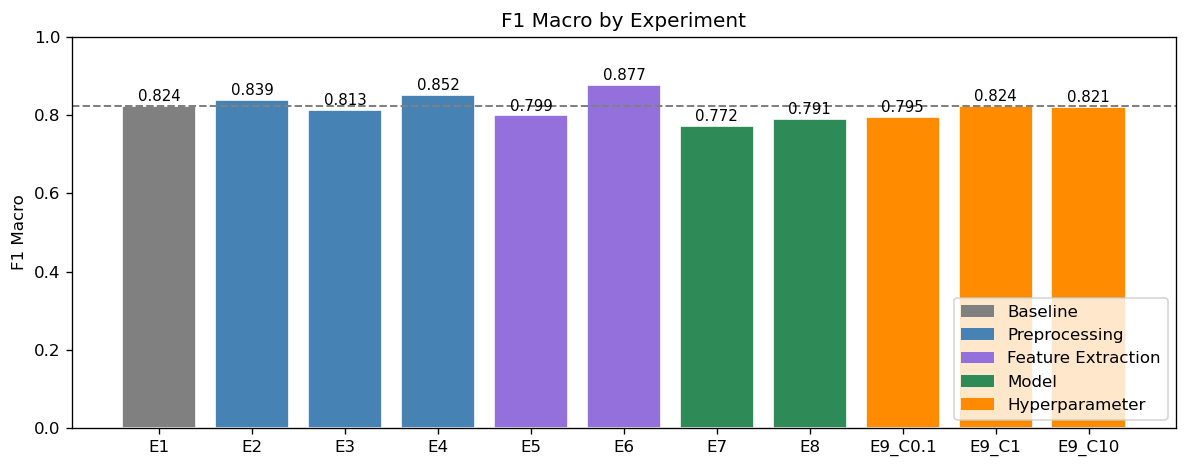

In [17]:
# Bar chart
colors = ['gray'] + ['steelblue']*3 + ['mediumpurple']*2 + ['seagreen']*2 + ['darkorange']*3

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.bar(df_results['ID'], df_results['F1 Macro'], color=colors, edgecolor='white')

baseline_f1 = df_results.loc[df_results['ID'] == 'E1', 'F1 Macro'].values[0]
ax.axhline(baseline_f1, color='gray', linestyle='--', linewidth=1.2, label=f'Baseline ({baseline_f1})')

for bar, val in zip(bars, df_results['F1 Macro']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{val:.3f}', ha='center', va='bottom', fontsize=9)

legend_elements = [
    Patch(facecolor='gray',         label='Baseline'),
    Patch(facecolor='steelblue',    label='Preprocessing'),
    Patch(facecolor='mediumpurple', label='Feature Extraction'),
    Patch(facecolor='seagreen',     label='Model'),
    Patch(facecolor='darkorange',   label='Hyperparameter'),
]
ax.legend(handles=legend_elements, loc='lower right')
ax.set_ylim(0, 1.0)
ax.set_ylabel('F1 Macro')
ax.set_title('F1 Macro by Experiment')
plt.tight_layout()
plt.savefig('figures/fig_results_f1.png', bbox_inches='tight')
plt.show()

In [18]:
# Delta vs Baseline
print(f"Baseline (E1): F1 Macro = {baseline_f1}\n")
print("Delta vs Baseline:")
for _, row in df_results.iterrows():
    delta = row['F1 Macro'] - baseline_f1
    sign = '+' if delta >= 0 else ''
    print(f"  {row['ID']}  {row['Name']:<30}  {sign}{delta:.4f}")

Baseline (E1): F1 Macro = 0.8235

Delta vs Baseline:
  E1  Baseline                        +0.0000
  E2  No Preprocessing                +0.0150
  E3  Stopwords only                  -0.0106
  E4  Stemming only                   +0.0288
  E5  Bag of Words                    -0.0241
  E6  TF-IDF 5000 features            +0.0531
  E7  Logistic Regression             -0.0510
  E8  Naive Bayes                     -0.0328
  E9_C0.1  SVM C=0.1                       -0.0284
  E9_C1  SVM C=1 (Baseline)              +0.0000
  E9_C10  SVM C=10                        -0.0024
